In [1]:
import pandas as pd
import numpy as np

Classes: ['test', 'train', 'valid']
Number of classes: 3
Total images: 1000

Images per class:
test: 100
train: 700
valid: 200


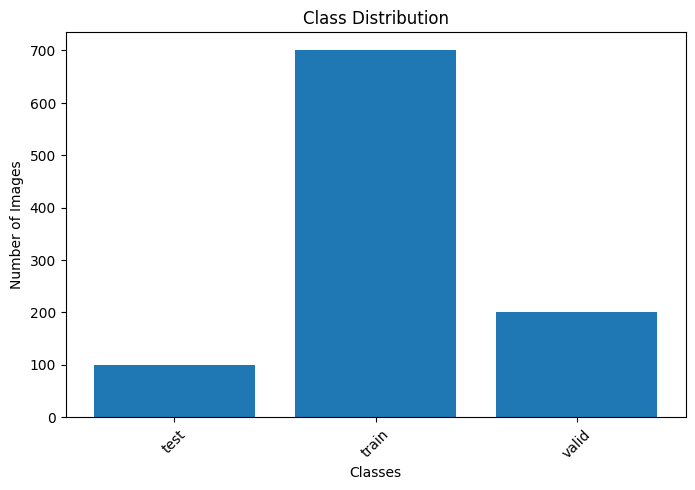

In [2]:
import os
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image
import torch
import torchvision.transforms as transform
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

root_dir = "Remote_Sensing_Data.v2i.yolov8"

dataset = ImageFolder(root_dir, transform=transform)
print("Classes:", dataset.classes)
print("Number of classes:", len(dataset.classes))
print("Total images:", len(dataset))

labels = [label for _, label in dataset.samples]
class_counts = Counter(labels)

print("\nImages per class:")
for class_idx, count in class_counts.items():
    print(f"{dataset.classes[class_idx]}: {count}")


plt.figure(figsize=(8,5))
plt.bar([dataset.classes[i] for i in class_counts.keys()],
        [class_counts[i] for i in class_counts.keys()])
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

In [3]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

dataset = ImageFolder("Remote_Sensing_Data.v2i.yolov8/", transform=transform)

train_size = int(0.8*len(dataset))
test_size = len(dataset)-train_size

train_ds, test_ds = torch.utils.data.random_split(dataset,[train_size,test_size])

train_loader = DataLoader(train_ds,batch_size=32,shuffle=True)
test_loader = DataLoader(test_ds,batch_size=32)

In [4]:
import torch.nn as nn
import torchvision.models as models

model = models.resnet18(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 3)  



d:\sarah_venv\sarah_venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\sarah_venv\sarah_venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

for epoch in range(1):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 1.0306308269500732


In [6]:
correct = 0
total = 0

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Accuracy:", correct/total)

Accuracy: 0.515


In [7]:
image_score = preds.float().mean().item()

In [8]:
import os
import cv2

img_folder = root_dir + "/train/images"
images = os.listdir(img_folder)

img1 = cv2.imread(os.path.join(img_folder, images[0]))
img2 = cv2.imread(os.path.join(img_folder, images[1]))

if img1 is None or img2 is None:
    print("Error loading images")
else:
    diff = cv2.absdiff(img1, img2)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)

    change_score = thresh.sum() / thresh.size
    print("Deforestation Score:", change_score)

Deforestation Score: 189.42901611328125


In [9]:


import pandas as pd
import numpy as np
import torch
import torch.nn as nn


df = pd.read_csv("D:\\sarah_venv\\sarah_venv\\all countries global temperature.csv")
print(df.shape)

df = df[df['Country Name'] == 'India']  


df_long = df.melt(
    id_vars=['Country Name'],
    value_vars=[str(year) for year in range(1970, 2022)],
    var_name='Year',
    value_name='Temperature'
)


df_long['Year'] = df_long['Year'].astype(int)
df_long['Temperature'] = df_long['Temperature'].astype(float)

# Sort
df_long = df_long.sort_values('Year')


temp_data = df_long['Temperature'].values

max_val = np.max(temp_data)
temp_data = temp_data / max_val


def create_sequences(data, seq_length=5):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(temp_data)

# Convert to tensor
X = torch.tensor(X).float().unsqueeze(-1)
y = torch.tensor(y).float()


class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 32, batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

model_lstm = LSTMModel()


criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.01)

for epoch in range(50):
    output = model_lstm(X)
    loss = criterion(output.squeeze(), y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()




X_test = X[-1].unsqueeze(0)

temp_pred = model_lstm(X_test).item()
temp_pred_real = temp_pred * max_val

print("Predicted Temperature:", temp_pred_real)


temp_score = temp_pred
print("Temperature Score:", temp_score)


(227, 56)
Predicted Temperature: 0.669281143784523
Temperature Score: 0.591760516166687


In [10]:
import pandas as pd


ndvi_df = pd.read_csv("D:\\sarah_venv\\sarah_venv\\NDVI Prediction.csv")
print(ndvi_df.shape)

(1048575, 4)


In [11]:
ndvi_df.head()

,PRECIPITATION,LST,ETo,NDVI
0,2209.311025,27.201892,461.1,0.4389
1,2209.311025,27.201892,461.1,0.4389
2,2209.311025,27.201892,461.1,0.4389
3,2209.311025,27.201892,461.1,0.4389
4,2209.311025,27.201892,461.1,0.4389


In [12]:
ndvi_df['NDVI'] = pd.to_numeric(ndvi_df['NDVI'], errors='coerce')

ndvi_df = ndvi_df.dropna(subset=['NDVI'])

In [13]:
def ndvi_to_score(ndvi):
    if ndvi < 0.2:
        return 0.2   # poor vegetation
    elif ndvi < 0.5:
        return 0.5   # moderate
    else:
        return 1.0   # healthy

ndvi_df['ndvi_score'] = ndvi_df['NDVI'].apply(ndvi_to_score)

final_ndvi_score = ndvi_df['ndvi_score'].mean()

print("Final NDVI Score:", final_ndvi_score)

Final NDVI Score: 0.5469512433540757


In [14]:
weather_df=pd.read_csv("D:\\sarah_venv\\sarah_venv\\climate_change_dataset.csv")
print(weather_df.shape)

(1000, 10)


In [15]:
weather_df.head()

,Year,Country,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
0,2006,UK,8.9,9.3,3.1,1441,530911230,20.4,14,59.8
1,2019,USA,31.0,4.8,4.2,2407,107364344,49.2,8,31.0
2,2014,France,33.9,2.8,2.2,1241,441101758,33.3,9,35.5
3,2010,Argentina,5.9,1.8,3.2,1892,1069669579,23.7,7,17.7
4,2007,Germany,26.9,5.6,2.4,1743,124079175,12.5,4,17.4


In [16]:
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

In [17]:
weather_df = weather_df[['CO2 Emissions (Tons/Capita)', 'Rainfall (mm)', 'Renewable Energy (%)']]

weather_df = weather_df.apply(pd.to_numeric, errors='coerce')
weather_df = weather_df.dropna()


In [18]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(weather_df)

# Split features
co2 = scaled_data[:, 0]
rain = scaled_data[:, 1]
energy = scaled_data[:, 2]

In [19]:
def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32).view(-1,1)

co2_tensor = to_tensor(co2)
rain_tensor = to_tensor(rain)
energy_tensor = to_tensor(energy)

In [20]:
class SimpleFFNN(nn.Module):
    def __init__(self):
        super(SimpleFFNN, self).__init__()
        
        self.fc1 = nn.Linear(1, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 1)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [21]:
rain_model = SimpleFFNN()
optimizer = torch.optim.Adam(rain_model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(10):
    output = rain_model(rain_tensor)
    loss = criterion(output, rain_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

rain_score = rain_model(rain_tensor).mean().item()
print("Rainfall Score:", rain_score)

Rainfall Score: -0.11516039818525314


In [22]:
co2_model = SimpleFFNN()
optimizer = torch.optim.Adam(co2_model.parameters(), lr=0.001)

for epoch in range(10):
    output = co2_model(co2_tensor)
    loss = criterion(output, co2_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

co2_score = co2_model(co2_tensor).mean().item()
print("CO2 Score:", co2_score)

CO2 Score: 0.1460840404033661


In [23]:
energy_model = SimpleFFNN()
optimizer = torch.optim.Adam(energy_model.parameters(), lr=0.001)

for epoch in range(10):
    output = energy_model(energy_tensor)
    loss = criterion(output, energy_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

energy_score = energy_model(energy_tensor).mean().item()
print("Energy Score:", energy_score)

Energy Score: 0.14456912875175476


In [24]:

print("Rain:", rain_score)
print("CO2:", co2_score)
print("Energy:", energy_score)

Rain: -0.11516039818525314
CO2: 0.1460840404033661
Energy: 0.14456912875175476


In [26]:
def forest_health_score(image_score, temp_score, deforestation_score,
                        ndvi_score, rain_score, co2_score, energy_score):
    
    # Weighted combination (all weights sum = 1)
    score = (
        0.20 * image_score +          # CNN vegetation
        0.15 * temp_score +           # temperature (LSTM)
        0.15 * deforestation_score +  # forest loss
        0.15 * ndvi_score +           # NDVI vegetation index
        0.15 * rain_score +           # rainfall
        0.10 * co2_score +            # CO2 emissions
        0.10 * energy_score           # renewable energy
    )
    
    return score

In [27]:
final_score = forest_health_score(
    image_score,
    temp_pred,
    change_score,
    final_ndvi_score,
    rain_score,
    co2_score,
    energy_score
)

print("Final Forest Health Score:", final_score)

Final Forest Health Score: 28.821950438108026


In [33]:
! pip install mlflow

INFO: pip is looking at multiple versions of fastapi to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   -------- ------------------------------- 2.1/10.5 MB 11.0 MB/s eta 0:00:01
   -------------- ------------------------- 3.7/10.5 MB 8.9 MB/s eta 0:00:01
   ------------------ --------------------- 4.7/10.5 MB 7.6 MB/s eta 0:00:01
   ----------------------- ---------------- 6.0/10.5 MB 7.2 MB/s eta 0:00:01
   ----------------------------- ---------- 7.6/10.5 MB 7.4 MB/s eta 0:00:01
   ------------------------------------ --- 9.4/10.5 MB 7.6 MB/s eta 0:00:01
   ---------------------------------------- 10.5/10.5 MB 7.6 MB/s  0:00:01
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ----------------------- ---------------- 1.8/3.2 MB 10.6 MB/s eta 0:00:01
   ---------------------------------------- 3.2/3.2 MB 8.3 MB/s  0:00:00
   --------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import os
import mlflow
from PIL import Image

d:\sarah_venv\sarah_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
image_folder = r"D:\\sarah_venv\\sarah_venv\\Remote_Sensing_Data.v2i.yolov8\\test\\images"

In [30]:
image_list = [
    os.path.join(image_folder, img)
    for img in os.listdir(image_folder)
    if img.endswith((".jpg", ".png"))
]

# Take only 20 images
image_list = image_list[:20]

print("Total Images:", len(image_list))

Total Images: 20


In [31]:
def forest_health_score(image_score, temp_score, change_score,
                        final_ndvi_score, rain_score, co2_score, energy_score):

    return (
        0.20 * image_score +
        0.15 * temp_score +
        0.15 * change_score +
        0.15 * final_ndvi_score +
        0.15 * rain_score +
        0.10 * co2_score +
        0.10 * energy_score
    )

In [32]:
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("Forest_Project")

d:\sarah_venv\sarah_venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
Traceback (most recent call last):
  File "d:\sarah_venv\sarah_venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "d:\sarah_venv\sarah_venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "d:\sarah_venv\sarah_venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, 

<Experiment: artifact_location='file:d:/sarah_venv/sarah_venv/mlruns/713506166550888184', creation_time=1777476157306, experiment_id='713506166550888184', last_update_time=1777476157306, lifecycle_stage='active', name='Forest_Project', tags={}, trace_location=None, workspace='default'>

In [33]:
import mlflow.pyfunc

class ForestHealthModel(mlflow.pyfunc.PythonModel):
    def predict(self, context, model_input):
        return [0.6]   # you can replace later

d:\sarah_venv\sarah_venv\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [ ]:
import os
import mlflow
import numpy as np
from PIL import Image
import random
import mlflow.pyfunc


image_folder = r"D:\sarah_venv\sarah_venv\Remote_Sensing_Data.v2i.yolov8\test\images"

image_list = [
    os.path.join(image_folder, img)
    for img in os.listdir(image_folder)
    if img.lower().endswith((".jpg", ".png", ".jpeg"))
]

image_list = image_list[:20]

print("Total images:", len(image_list))

if len(image_list) == 0:
    raise Exception(" No images found! Fix your path.")


def get_image_score(img_path):
    img = Image.open(img_path).convert("L")
    arr = np.array(img)
    return float(arr.mean() / 255)


def get_ndvi_score(img_path):
    img = Image.open(img_path)
    arr = np.array(img)
    return float(arr.std() / 255)


def forest_health_score(image, temp, defor, ndvi, rain, co2, energy):
    return (
        0.3 * image +
        0.1 * temp +
        0.1 * defor +
        0.2 * ndvi +
        0.1 * rain +
        0.1 * co2 +
        0.1 * energy
    )


class ForestHealthModel(mlflow.pyfunc.PythonModel):

    def predict(self, context, model_input):
        image = model_input["image_score"][0]
        temp = model_input["temp_score"][0]
        defor = model_input["deforestation_score"][0]
        ndvi = model_input["ndvi_score"][0]
        rain = model_input["rain_score"][0]
        co2 = model_input["co2_score"][0]
        energy = model_input["energy_score"][0]

        return [
            forest_health_score(image, temp, defor, ndvi, rain, co2, energy)
        ]


mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("Forest_Project")

results = []


with mlflow.start_run() as run:

    print("Run ID:", run.info.run_id)

    
    mlflow.pyfunc.log_model(
        artifact_path="forest_model",
        python_model=ForestHealthModel()
    )

    for i, img_path in enumerate(image_list):

        print("Processing:", img_path)

        # Image-based scores
        image_score = get_image_score(img_path)
        ndvi_score = get_ndvi_score(img_path)

        # Variable environmental values
        temp_score = random.uniform(0.3, 0.7)
        change_score = random.uniform(0.2, 0.6)
        rain_score = random.uniform(0.3, 0.8)
        co2_score = random.uniform(0.2, 0.7)
        energy_score = random.uniform(0.3, 0.9)

        # Final score
        final_score = forest_health_score(
            image_score,
            temp_score,
            change_score,
            ndvi_score,
            rain_score,
            co2_score,
            energy_score
        )

        results.append((img_path, final_score))

        
        mlflow.log_metric(f"image_{i}_score", float(final_score))

        
        mlflow.log_artifact(img_path)

        print(f"{img_path} → {final_score}")

    
    avg_score = sum([r[1] for r in results]) / len(results)
    mlflow.log_metric("avg_forest_score", float(avg_score))

    print("Average Score:", avg_score)

d:\sarah_venv\sarah_venv\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
Traceback (most recent call last):
  File "d:\sarah_venv\sarah_venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "d:\sarah_venv\sarah_venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "d:\sarah_venv\sarah_venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "d:\sarah_venv\sarah_venv\Lib\site-packages\mlflow\store\tr

Total images: 20


2026/05/03 00:22:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 00:22:53 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


Run ID: 5539b728be244af6b0445d05e30ff295
Processing: D:\sarah_venv\sarah_venv\Remote_Sensing_Data.v2i.yolov8\test\images\015_jpg.rf.0c375710767d68c292906477a5f53a5f.jpg
D:\sarah_venv\sarah_venv\Remote_Sensing_Data.v2i.yolov8\test\images\015_jpg.rf.0c375710767d68c292906477a5f53a5f.jpg → 0.485527870678081
Processing: D:\sarah_venv\sarah_venv\Remote_Sensing_Data.v2i.yolov8\test\images\018_jpg.rf.721ff66c0623de6e3478dc26418901f1.jpg
D:\sarah_venv\sarah_venv\Remote_Sensing_Data.v2i.yolov8\test\images\018_jpg.rf.721ff66c0623de6e3478dc26418901f1.jpg → 0.5376278693265198
Processing: D:\sarah_venv\sarah_venv\Remote_Sensing_Data.v2i.yolov8\test\images\028_jpg.rf.c5f53fb7c6db8114115917cb0661ae5a.jpg
D:\sarah_venv\sarah_venv\Remote_Sensing_Data.v2i.yolov8\test\images\028_jpg.rf.c5f53fb7c6db8114115917cb0661ae5a.jpg → 0.3749808025472674
Processing: D:\sarah_venv\sarah_venv\Remote_Sensing_Data.v2i.yolov8\test\images\032_jpg.rf.64b1ff10f0481ac533afd187ab1ec915.jpg
D:\sarah_venv\sarah_venv\Remote_Sensi

In [43]:
import requests

data = {
    "inputs": {
        "image_score": [0.7],
        "temp_score": [0.5],
        "deforestation_score": [0.4],
        "ndvi_score": [0.6],
        "rain_score": [0.8],
        "co2_score": [0.3],
        "energy_score": [0.5]
    }
}

response = requests.post(
    "http://127.0.0.1:8000/invocations",
    json=data
)

print("Forest Health Score:", response.json())

Forest Health Score: {'predictions': [0.5800000000000001]}


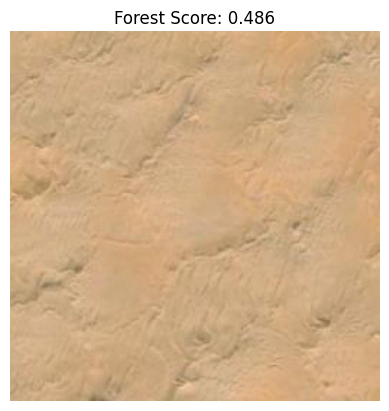

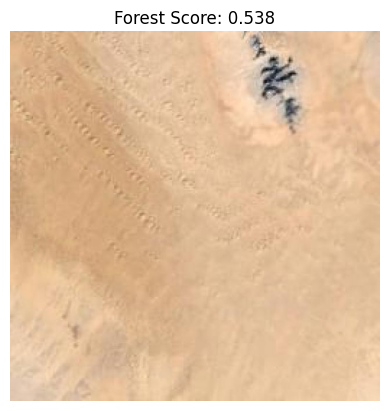

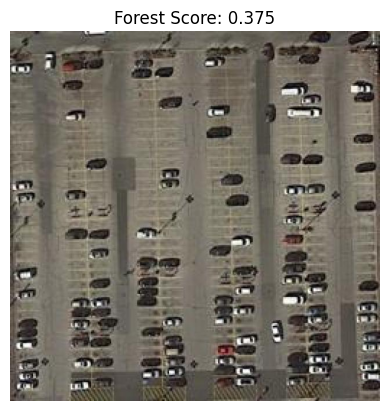

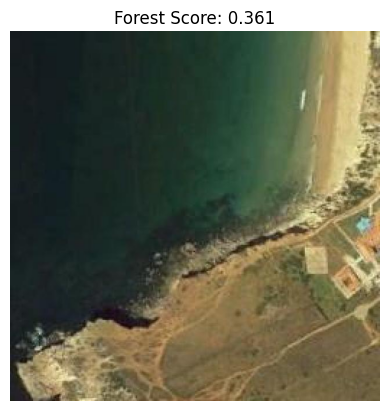

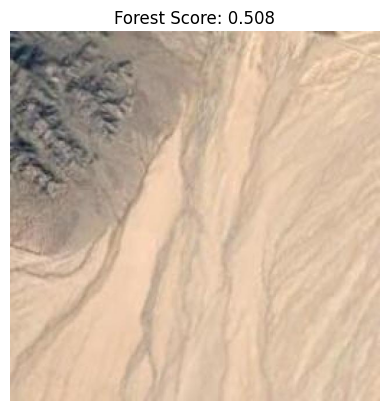

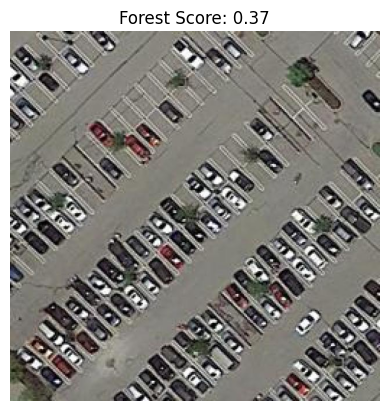

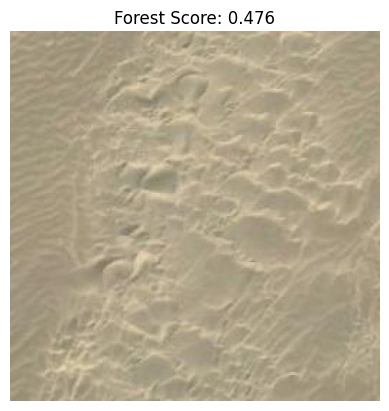

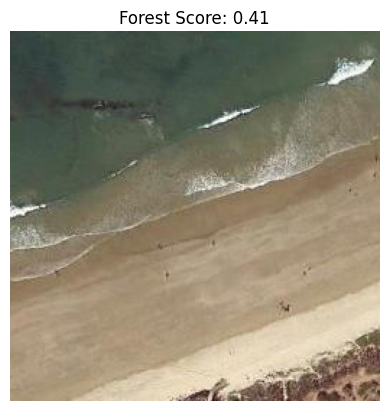

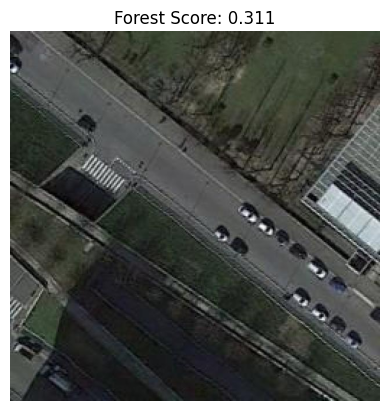

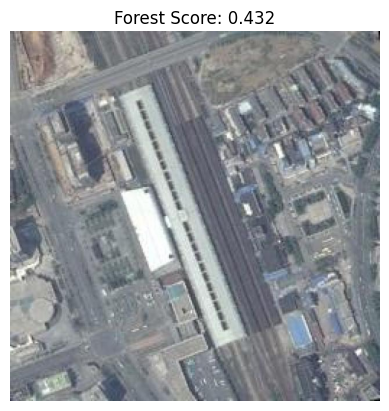

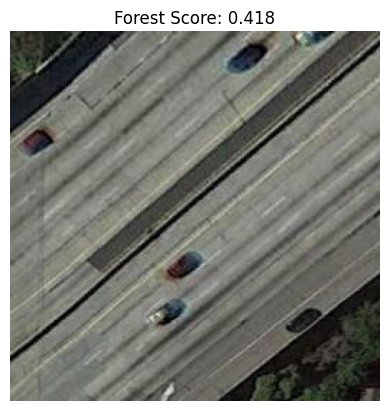

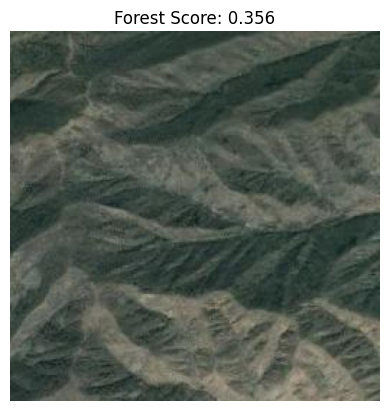

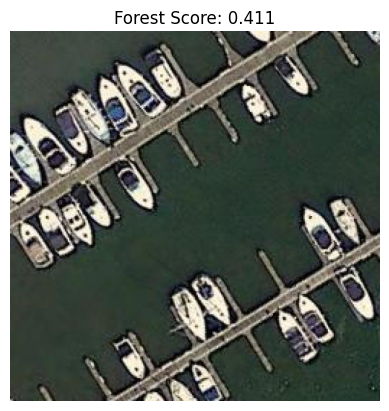

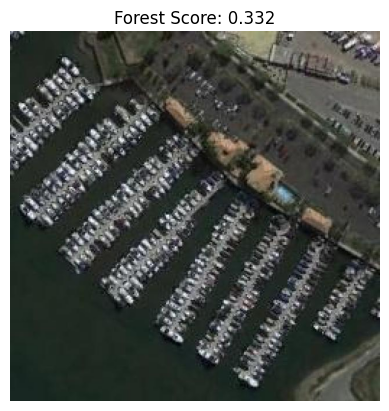

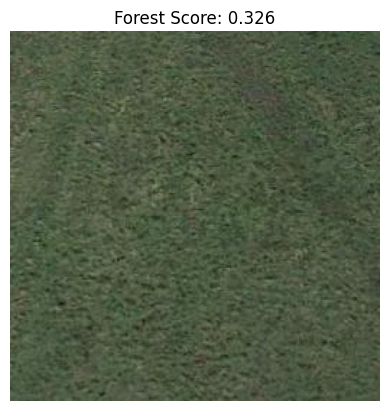

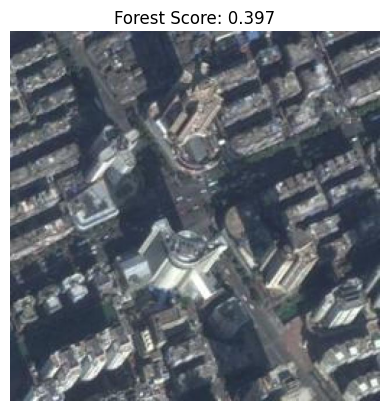

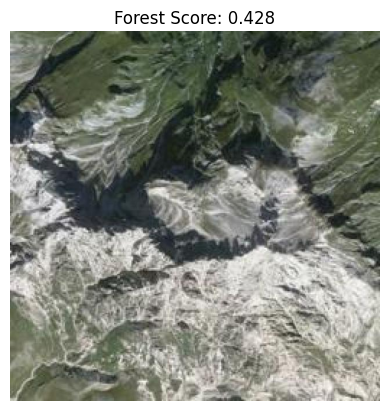

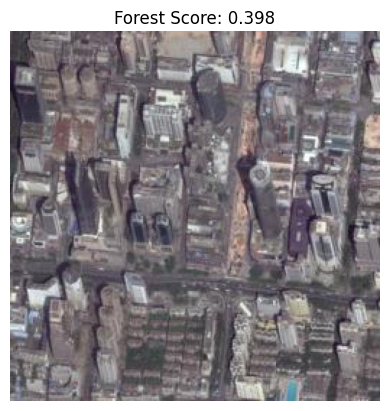

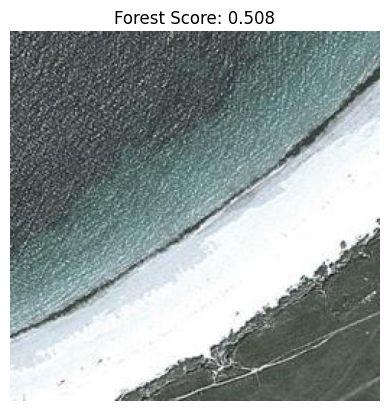

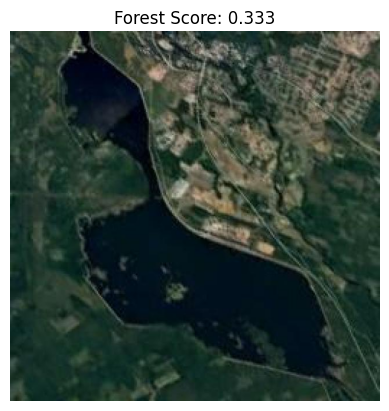

In [44]:
import matplotlib.pyplot as plt

for img_path, score in results:
    img = Image.open(img_path)

    plt.imshow(img)
    plt.title(f"Forest Score: {round(score, 3)}")
    plt.axis("off")
    plt.show()